# 04 - Transition-state endpoint representations

This notebook compares standard transition-state endpoints with the additional-sampling representation obtained by fixing atoms incident to changed bonds and rescanning the remaining atoms. The additional-sampling result does not replace the standard inference.

In practice, retain the standard endpoint conformers before calling the additional-sampling API:

```python
standard_pre, standard_post = ts_frame.possible_pre_post_ts(show_3D=True)
additional_pre, additional_post = ts_frame.additional_pre_post_ts(
    standard_pre, standard_post
)
```

The code below reads a bundled Gaussian TS output, performs both the standard endpoint inference and additional sampling in MolOP, and then draws the returned molecules in the Notebook. The first row shows the standard endpoint pair; the second row shows the additional-sampling pair, with fragment counts in each legend. It also calls `to_diff_rdmol()` to inspect the bond-change difference graph.

input: ../../assets/examples/ts_endpoint_additional_sampling.log
standard endpoint fragments: 2 2
additional-sampling endpoint fragments: 3 2


difference graph bonds: 48
ZERO bonds in difference graph: 4


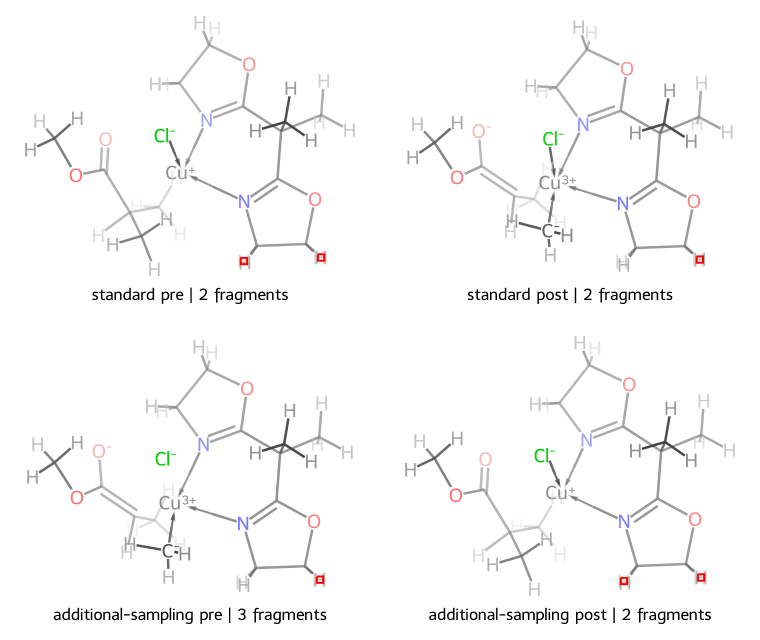

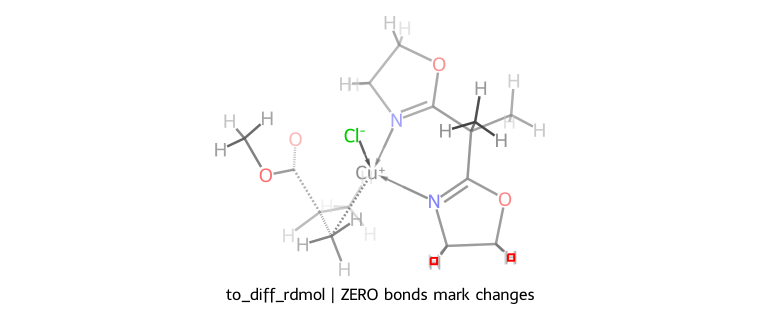

In [1]:
from pathlib import Path

from IPython.display import SVG, display
from rdkit import Chem
from rdkit_dof import MolsToGridDofImage

from molop import AutoParser, molopconfig

molopconfig.quiet()
sample_candidates = (
    Path("docs/assets/examples/ts_endpoint_additional_sampling.log"),
    Path("../../assets/examples/ts_endpoint_additional_sampling.log"),
    Path("ts_endpoint_additional_sampling.log"),
)
sample_path = next((path for path in sample_candidates if path.is_file()), None)
if sample_path is None:
    raise FileNotFoundError("Place ts_endpoint_additional_sampling.log beside the notebook or use the bundled example.")

batch = AutoParser(sample_path, n_jobs=1, only_last_frame=True)
ts_frame = next((frame for frame in batch[0] if frame.is_TS), None)
if ts_frame is None:
    raise ValueError("The sample file does not contain a transition-state frame.")

standard_pre, standard_post = ts_frame.possible_pre_post_ts(show_3D=True)
additional_pre, additional_post = ts_frame.additional_pre_post_ts(
    standard_pre, standard_post
)
endpoint_molecules = [standard_pre, standard_post, additional_pre, additional_post]
labels = [
    f"standard pre | {len(Chem.GetMolFrags(standard_pre))} fragments",
    f"standard post | {len(Chem.GetMolFrags(standard_post))} fragments",
    f"additional-sampling pre | {len(Chem.GetMolFrags(additional_pre))} fragments",
    f"additional-sampling post | {len(Chem.GetMolFrags(additional_post))} fragments",
]
print("input:", sample_path)
print("standard endpoint fragments:", len(Chem.GetMolFrags(standard_pre)), len(Chem.GetMolFrags(standard_post)))
print("additional-sampling endpoint fragments:", len(Chem.GetMolFrags(additional_pre)), len(Chem.GetMolFrags(additional_post)))

difference = ts_frame.to_diff_rdmol()
if difference is None:
    raise ValueError("The sample file did not produce a bond-change difference graph.")
changed_bonds = [
    bond for bond in difference.GetBonds() if bond.GetBondType() == Chem.BondType.ZERO
]
print("difference graph bonds:", difference.GetNumBonds())
print("ZERO bonds in difference graph:", len(changed_bonds))

svg = MolsToGridDofImage(
    endpoint_molecules,
    molsPerRow=2,
    subImgSize=(380, 320),
    legends=labels,
    use_svg=True,
    return_image=False,
)
if not isinstance(svg, str):
    raise RuntimeError("rdkit-dof did not return SVG output.")
display(SVG(data=svg))

difference_svg = MolsToGridDofImage(
    [difference],
    molsPerRow=1,
    subImgSize=(760, 320),
    legends=["to_diff_rdmol | ZERO bonds mark changes"],
    use_svg=True,
    return_image=False,
)
if not isinstance(difference_svg, str):
    raise RuntimeError("rdkit-dof did not return difference-graph SVG output.")
display(SVG(data=difference_svg))